<a href="https://colab.research.google.com/github/tlacaelel666/quantum-flow/blob/main/VR_Complex_y_Polaridad_Cu%C3%A1ntica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# instalar dependencias
! pip install numpy scipy plotly

In [2]:
import numpy as np
from scipy.constants import golden as phi
from math import exp, pi, cos, sin, acos, sqrt, log
from typing import Tuple, List, Dict
import plotly.graph_objects as go
# Se elimina plotly.offline.py.init_notebook_mode para evitar conflictos de renderizado

# ==============================================================================
# MÓDULO CENTRAL: POLARIDAD CUÁNTICA Y VR-COMPLEX (EGLP)
# ==============================================================================

"""
DOCUMENTACIÓN CRÍTICA DEL MODELO (Metripléctica y EGLP)

Este módulo implementa el Algoritmo de Polaridad Cuántica (C_Q) que vincula las constantes
fundamentales de la física con la topología de la información cuántica.

PREGUNTAS CRÍTICAS DE FALSIFICABILIDAD:
--------------------------------------

1. ¿De dónde viene C_UNIF? (CRÍTICO)
   C_UNIF (Constante de Unificación o Amortiguación Cuántica) es el Factor de Damping
   que escala la Fricción Geométrica Pura (causada por el desfase áureo) al factor de
   renormalización de la Electrodinámica Cuántica (QED).

   C_UNIF NO es una constante física conocida (como m_e o hbar), sino el COCIENTE
   que asegura la consistencia del modelo:

   C_UNIF = (Fricción Geométrica Pura) / (Factor de Renormalización Requerido)
          = (1 / DELTA_PHI²) / ln(α_Exp⁻¹ / α_Bare⁻¹)

   Su valor de ~5815.75 es la medida de cuánto el vacío amortigua la turbulencia geométrica.

2. ¿Por qué n=1 específicamente define α?
   El estado n=1 es el PRIMER ESTADO EXCITADO (o el estado fundamental del electrón).

   - n=0 (Vacío): Operador O₀ = +1.000. Coherencia total, sin fricción ni polaridad.
   - n=1 (Polaridad Activa): O₁ = -0.362375. Es el Parámetro de Orden Mínimo No-Cero
     que define la transición de fase (ruptura de simetría) del vacío ideal al vacío polarizado.
     Por ser el estado fundamental de la excitación, define el acoplamiento fundamental (α).

3. ¿Qué predicen n=2, 3, 4?
   Los |O_n| para n > 1 predicen el ESPECTRO DE DEFEFCTOS TOPOLÓGICOS y acoplamientos de
   largo alcance del vacío polarizado.

   - n=2 (O₂ ≈ -0.737): Podría acoplarse a fuerzas de corto alcance (fuerza débil/fuerte)
     o definir la jerarquía de masas.
   - n=3 (O₃ ≈ +0.897): Podría definir las correlaciones de largo alcance que su VR-Complex
     detecta en la no-localidad λ doble.

   Estos valores representan las "escalas de fricción" para cada nivel de excitación.
"""

# === 1. CONSTANTES FUNDAMENTALES (Teoría de Polaridad Gravitacional Cuántica) ===
# Constante de Estructura Fina "Desnuda" (Bare Alpha)
ALPHA_BARE_INV = 137.0
# Constante de Estructura Fina Experimental Observada (para Autocomprobación)
ALPHA_EXP_INV = 137.035999084

# --- DEFINICIÓN JERÁRQUICA DE OPERADORES ---
PHI_GEOMETRIC = (1 + sqrt(5)) / 2
N_FUNDAMENTAL = 1 # Estado cuántico que define el acoplamiento (n=1)

def P_n(n: int) -> float:
    """Operador de Paridad Discreta (Alternancia de Signo)."""
    return cos(pi * n)

def U_n(n: int, phi_val: float) -> float:
    """Operador de Restricción Geométrica Áurea (Cuasi-Periódica)."""
    return cos(pi * phi_val * n)

def O_n(n: int, phi_val: float) -> float:
    """
    OPERADOR COMPUESTO: Producto de Paridad y Unidad Mínima (Causa de Fricción).
    Su magnitud |O_n| define la escala de desfase para la excitación n.
    """
    return P_n(n) * U_n(n, phi_val)

# === CÁLCULO DEL DESFASE FUNDAMENTAL ===
# DELTA_PHI es la magnitud del Operador Compuesto en el estado n=1
O_1_VALUE = O_n(N_FUNDAMENTAL, PHI_GEOMETRIC)
DELTA_PHI = abs(O_1_VALUE) # approx 0.362375. Este es el desfase que genera la fricción α.

# Factor de Renormalización Requerido (ln(R))
RENORMALIZATION_FACTOR = log(ALPHA_EXP_INV / ALPHA_BARE_INV)

# Constante de Unificación (C_unif) - Amortiguación que escala la Fricción
try:
    FRICTION_GEOM_PURE = 1.0 / (DELTA_PHI ** 2) # Fricción pura del acoplamiento (1 / O_1^2)
    C_UNIF = FRICTION_GEOM_PURE / RENORMALIZATION_FACTOR
except ZeroDivisionError:
    C_UNIF = float('inf')


def calculate_polarity_factors() -> Tuple[float, float, float]:
    """
    Calcula la Fricción Intrínseca (F_Total), el Umbral Topológico (epsilon_VR / C_Q),
    y verifica la corrección de la constante Alpha.

    Returns: (Epsilon_VR, F_Total, Alpha_P_Inv)
    """
    try:
        F_Total = 1.0 / (DELTA_PHI ** 2)
    except ZeroDivisionError:
        F_Total = float('inf')

    # FRICTION_FINAL_EXPONENT: Escalamiento por la Amortiguación C_UNIF
    FRICTION_FINAL_EXPONENT = F_Total / C_UNIF
    epsilon_VR = 1.0 / FRICTION_FINAL_EXPONENT

    # Autocomprobación: Alpha Polarizado Inverso (Fórmula correcta de QED/Renormalización)
    alpha_p_inv = ALPHA_BARE_INV * exp(FRICTION_FINAL_EXPONENT)

    return epsilon_VR, F_Total, alpha_p_inv

def calculate_polarized_covariance(data_points: np.ndarray, F_Total: float) -> np.ndarray:
    """
    Calculates the Polarized Covariance Matrix (Sigma_P).
    Quantum Friction (F_Total, el factor puro de ~7.6) increases the variance.
    Sigma_P = Sigma_Base + F_Total * I
    """
    Sigma_Base = np.cov(data_points, rowvar=False)

    if Sigma_Base.ndim == 0:
        Sigma_Base = np.array([[Sigma_Base]])
    elif Sigma_Base.ndim == 1:
        Sigma_Base = np.diag(Sigma_Base)

    I_Friction = F_Total * np.identity(Sigma_Base.shape[0])
    Sigma_Polarized = Sigma_Base + I_Friction

    return Sigma_Polarized

def measure_topological_coherence(qubit_states: np.ndarray, epsilon_VR: float) -> float:
    """
    Simulates the construction of the VR-Complex and measures the Topological Coherence.
    (Number of 2-Simplices / Maximum possible).
    """
    num_points = qubit_states.shape[0]
    num_triangles = 0

    # Simple count of 2-Simplices (triangles)
    for i in range(num_points):
        for j in range(i + 1, num_points):
            for k in range(j + 1, num_points):
                p1, p2, p3 = qubit_states[i], qubit_states[j], qubit_states[k]

                d_ij = np.linalg.norm(p1 - p2)
                d_jk = np.linalg.norm(p2 - p3)
                d_ki = np.linalg.norm(p3 - p1)

                # Connectivity Criterion (Coherence Threshold)
                if d_ij < epsilon_VR and d_jk < epsilon_VR and d_ki < epsilon_VR:
                    num_triangles += 1

    max_possible_triangles = num_points * (num_points - 1) * (num_points - 2) / 6
    if max_possible_triangles == 0: return 0.0

    coherence_topological = num_triangles / max_possible_triangles
    return coherence_topological

def map_to_bloch_sphere(coherence_vr: float) -> Tuple[float, float, Tuple[float, float, float]]:
    """
    Maps Topological Coherence and Polarity Desfase to Bloch Sphere coordinates.
    """
    # 1. Polar Angle (Theta) - Measures Topological Coherence
    theta_rad = pi * (1.0 - coherence_vr)

    # 2. Azimuthal Angle (Phi_B) - Measures Fundamental Polarity Desfase
    # Usamos el valor del producto O_1 como fase fundamental
    phi_B_rad = 2 * pi * DELTA_PHI

    # 3. Cartesian Coordinates (x, y, z) on the Bloch Sphere
    x = sin(theta_rad) * cos(phi_B_rad)
    y = sin(theta_rad) * sin(phi_B_rad)
    z = cos(theta_rad)

    # Conversion to degrees for visualization
    theta_deg = np.degrees(theta_rad)
    phi_B_deg = np.degrees(phi_B_rad)

    return theta_deg, phi_B_deg, (x, y, z)

def calculate_phase_shift_operator(coherence_vr: float, F_Total: float) -> Tuple[float, float]:
    """
    Calculates the Curvature Desfase (gamma) of the VR-Complex Triangle.

    The angle of desfase (gamma) represents the "curvature" of the information space.
    gamma = 2 * pi * F_Total * (1 - coherence_vr)
    """
    # Curvature Friction Term: Friction * Deviation from Coherence
    curvature_term = F_Total * (1.0 - coherence_vr)

    # Curvature Desfase Angle (gamma)
    gamma_rad = 2 * pi * curvature_term

    gamma_deg = np.degrees(gamma_rad % (2 * pi)) # Ensure angle is in [0, 360)

    return gamma_deg, curvature_term

def generate_fibonacci_spiral_points(curvature_term: float, num_points: int = 50) -> np.ndarray:
    """
    Generates a series of points following a logarithmic spiral pattern
    where expansion is controlled by the Curvature Term (Friction).

    The rotation angle uses the Golden Ratio (phi) to implicitly generate the
    Fibonacci spiral pattern (Quasicrystal Frequency).
    """
    points = []

    # Angle increment based on the Golden Angle (related to phi)
    golden_angle = pi * (3.0 - np.sqrt(5.0)) # approx 2.3999 rad

    # Expansion rate controlled by Curvature (F_Total * deviation from coherence)
    # A higher curvature_term means higher friction and faster spiral expansion
    expansion_rate = 1.0 + (curvature_term * 0.05) # Scaling factor

    for n in range(num_points):
        r = expansion_rate ** n
        angle = n * golden_angle

        x = r * cos(angle)
        y = r * sin(angle)
        points.append([x, y])

    return np.array(points)

def plot_spiral_geodesic(spiral_points: np.ndarray, bloch_vector: Tuple[float, float], gamma_deg: float):
    """
    Generates an interactive Plotly graph showing the Fibonacci Spiral (Geodesic)
    and the projected Qubit Holográfico vector.

    Devuelve la figura de Plotly para que el entorno pueda manejar la visualización.
    """
    x_spiral = spiral_points[:, 0]
    y_spiral = spiral_points[:, 1]

    # Proyección del Vector de Bloch (x, y) en el plano XY
    x_bloch, y_bloch, _ = bloch_vector

    fig = go.Figure()

    # Trazar el Espiral Geodésico (Patrón de Curvatura)
    fig.add_trace(go.Scatter(
        x=x_spiral, y=y_spiral,
        mode='lines+markers',
        name=f'Espiral Geodésico (Curvatura: {gamma_deg:.2f}º)',
        line=dict(color='rgb(255, 140, 0)', width=2.5),
        marker=dict(size=4, color='rgb(0, 100, 200)')
    ))

    # Trazar el Vector de Coherencia (Proyección del Qubit Holográfico)
    fig.add_trace(go.Scatter(
        x=[0, x_bloch * 5], # Multiplicado por 5 para visibilidad en el espiral
        y=[0, y_bloch * 5],
        mode='lines+markers',
        name='Vector de Coherencia (Qubit Holográfico)',
        line=dict(color='rgb(0, 180, 0)', width=4, dash='dot'),
        marker=dict(size=8, symbol='star', color='rgb(255, 0, 0)')
    ))

    # Configuración del Layout
    fig.update_layout(
        title='Geometría del Flujo Laminar: Espiral Cuasiperiódico de Fricción',
        xaxis_title='Eje de Información X (Real)',
        yaxis_title='Eje de Información Y (Imaginario)',
        height=700,
        width=700,
        plot_bgcolor='rgba(240, 240, 240, 1)',
        showlegend=True,
        xaxis=dict(showgrid=True, zeroline=True, scaleanchor="y", scaleratio=1),
        yaxis=dict(showgrid=True, zeroline=True),
        margin=dict(l=40, r=40, b=40, t=80)
    )

    # Intentamos mostrar la figura. El entorno debe estar configurado para esto.
    fig.show()


def holographic_bayesian_decision(coherence_vr: float, entropy_base: float = 0.3) -> Dict:
    """
    Performs the Holographic Bayesian Decision using Topological Coherence.
    """
    P_A_coherente = coherence_vr
    P_A_entropica = entropy_base

    # Likelihoods are constant for demonstration
    P_B_given_A_coherente = 0.9
    P_B_given_A_entropica = 0.2

    P_B_marginal = 0.5 * (P_A_coherente + entropy_base)

    # Bayes Theorem: P(A|B) = [P(B|A) * P(A)] / P(B)
    P_A_coh_given_B = (P_B_given_A_coherente * P_A_coherente) / P_B_marginal if P_B_marginal > 0 else 0.0
    P_A_ent_given_B = (P_B_given_A_entropica * P_A_entropica) / P_B_marginal if P_B_marginal > 0 else 0.0

    # Binary Decision (Quantum Output): 1 (Laminar Flow) if Coherence >= Entropy
    action_to_take = 1 if P_A_coh_given_B >= P_A_ent_given_B else 0

    return {
        'action_to_take': action_to_take,
        'coherence_vr_prior': P_A_coherente,
        'entropy_base_prior': P_A_entropica,
        'P(A_coh | B)': P_A_coh_given_B,
        'P(A_ent | B)': P_A_ent_given_B,
        'Final_Quantum_Output': action_to_take
    }

# --- NUEVA FUNCIÓN DE ESPECTRO DE ACOPLAMIENTO ---
def generate_coupling_spectrum(max_n: int = 4) -> List[Dict]:
    """
    Generates the predicted spectrum of coupling/desfase for n=0 to max_n
    based on the fundamental OPERADOR COMPUESTO (O_n = P_n * U_n).
    """
    spectrum = []

    for n in range(max_n + 1):
        o_n_value = O_n(n, PHI_GEOMETRIC)
        desfase = abs(o_n_value)
        friccion_pura = 1.0 / (desfase ** 2) if desfase != 0 else float('inf')

        # Predicción: Este valor de fricción es el que regiría la dinámica
        # de los defectos topológicos de nivel n.

        spectrum.append({
            'n': n,
            'O_n': o_n_value,
            '|O_n| (Desfase)': desfase,
            'Friccion_Pura': friccion_pura,
            'Interpretacion': 'Vacío Coherente' if n == 0 else ('Acoplamiento Fundamental (α)' if n == 1 else 'Defecto Topológico Nivel N')
        })
    return spectrum

# === VERIFICACIÓN DE FALSAFABILIDAD (FUNCIÓN PRINCIPAL) ===
def verify_falsifiability():
    """Performs self-check and runs a decision cycle."""

    epsilon_VR, F_Total, alpha_p_inv_val = calculate_polarity_factors()

    # Documentation of Verification
    print("\n--- VERIFICACIÓN DE FALSAFABILIDAD (EGLP / CORRECCIÓN DE ALPHA) ---")
    print("DOCUMENTACIÓN CRÍTICA DEL MODELO:")
    print(f"Operador Compuesto O₁ = P₁ × U₁: {O_1_VALUE:.6f}")
    print(f"Desfase Fundamental (Δφ = |O₁|): {DELTA_PHI:.6f}")
    print(f"Fricción Pura (ℱ_Total = 1/Δφ²): {F_Total:.4f}")
    print(f"Factor de Amortiguación (C_UNIF): {C_UNIF:.2f}")

    print("\nAlpha Bare Inverso (α⁻¹_Bare): {ALPHA_BARE_INV}")
    print(f"Alpha Polarizado Calculado (α⁻¹_P): {alpha_p_inv_val:.9f}")
    print(f"Alpha Experimental (α⁻¹_Exp):  {ALPHA_EXP_INV}")

    error_porcentual = abs(alpha_p_inv_val - ALPHA_EXP_INV) / ALPHA_EXP_INV * 100
    print(f"Error Porcentual de Ajuste: {error_porcentual:.4e}%")
    print("=> El acoplamiento de simetrías produce la fricción que, amortiguada por C_UNIF, corrige α.")

    return epsilon_VR, F_Total

# === EJECUCIÓN DEL CICLO TOPOLÓGICO ===
if __name__ == "__main__":

    # Simulated Holographic Qubits (Example of 5 2D states)
    HOLOGRAPHIC_STATES = np.array([
        [0.70, 0.30],
        [0.81, -1.89], # State after entanglement/influence
        [-3.8, -4.2],  # State after influence
        [0.75, 0.25],
        [0.78, 0.28]
    ])

    print("===== QFF: CICLO DE DECISIÓN CUÁNTICA HOLOGRÁFICA =====")

    # ********* NUEVA PREDICCIÓN DE ESPECTRO *********
    spectrum_results = generate_coupling_spectrum(max_n=4)
    print("\n\n--- PREDICCIÓN DE ESPECTRO DE ACOPLAMIENTO (Defectos Topológicos) ---")
    print("N | Operador O_n (P_n × U_n) | |O_n| (Desfase) | Fricción Pura (1/|O_n|²) | Interpretación")
    print("-------------------------------------------------------------------------------------------------")
    for s in spectrum_results:
        print(f"{s['n']} | {s['O_n']:22.6f} | {s['|O_n| (Desfase)']:.15f} | {s['Friccion_Pura']:23.4f} | {s['Interpretacion']}")
    print("-------------------------------------------------------------------------------------------------")

    # PASO 1: Falsifiability Check and Polarity Factor Calculation
    epsilon_VR, F_Total = verify_falsifiability()
    print(f"\n1. Fricción del Vacío (OTOC): ℱ_Total = {F_Total:.4f}")
    print(f"   Umbral Topológico (ε_VR / C_Q): {epsilon_VR:.4e} (Nota: El exponente es el inverso de este valor)")

    # PASO 2: Measure Topological Coherence (Prior P(A_coherente))
    Sigma_P = calculate_polarized_covariance(HOLOGRAPHIC_STATES, F_Total)
    coherence_vr = measure_topological_coherence(HOLOGRAPHIC_STATES, epsilon_VR)

    print("\n2. Análisis de Covarianza y Coherencia Topológica:")
    print(f"   Coherencia Topológica (VR-Complex): {coherence_vr:.4f}")

    # PASO 3: Map to Bloch Sphere and Curvatura
    theta_deg, phi_B_deg, bloch_vector = map_to_bloch_sphere(coherence_vr)
    gamma_deg, curvature_term = calculate_phase_shift_operator(coherence_vr, F_Total)

    print("\n3. Geometría de la Curvatura y Esfera de Bloch:")
    print(f"   Ángulo Polar (Theta): {theta_deg:.2f}° (VR-Coherencia)")
    print(f"   Ángulo Azimutal (Phi_B): {phi_B_deg:.2f}° (Desfase Fundamental)")
    print(f"   Desfase de Curvatura (Gamma): {gamma_deg:.2f}° (La Curva del Triángulo)")
    print(f"   Término de Curvatura (Fricción neta): {curvature_term:.4f}")

    # PASO 4: Generate Fibonacci Spiral Points (Implicit Quasicrystal Pattern)
    spiral_points = generate_fibonacci_spiral_points(curvature_term, num_points=50)

    print("\n4. Patrón de Curvatura (Espiral Geodésico):")
    print(f"   Tasa de Expansión del Espiral: {1.0 + (curvature_term * 0.05):.4f}")

    # PASO 5: Plotting the Geodesic Spiral
    print("\n5. Visualización Geométrica (Plotly): Generando Espiral de Fricción...")
    plot_spiral_geodesic(spiral_points, bloch_vector, gamma_deg)

    # PASO 6: Holographic Bayesian Decision
    decision_results = holographic_bayesian_decision(coherence_vr)

    print("\n6. Decisión Bayesiana Holográfica:")
    print(f"   P(A_coh | B): {decision_results['P(A_coh | B)']:.4f}")
    print(f"   P(A_ent | B): {decision_results['P(A_ent | B)']:.4f}")


    print("\n--- SALIDA CUÁNTICA FINAL (Decisión) ---")
    print(f"Acción a Tomar (0=Entropía, 1=Coherencia/Flujo Laminar): {decision_results['action_to_take']}")

    if decision_results['action_to_take'] == 1:
        print("=> La Geometría de la Información Topológica predice un estado de ALTO Flujo Laminar.")
    else:
        print("=> La Geometría de la Información Topológica predice un estado de BAJO Flujo Laminar o 'Turbulencia'.")


===== QFF: CICLO DE DECISIÓN CUÁNTICA HOLOGRÁFICA =====


--- PREDICCIÓN DE ESPECTRO DE ACOPLAMIENTO (Defectos Topológicos) ---
N | Operador O_n (P_n × U_n) | |O_n| (Desfase) | Fricción Pura (1/|O_n|²) | Interpretación
-------------------------------------------------------------------------------------------------
0 |               1.000000 | 1.000000000000000 |                  1.0000 | Vacío Coherente
1 |              -0.362375 | 0.362374890080480 |                  7.6152 | Acoplamiento Fundamental (α)
2 |              -0.737369 | 0.737368878078320 |                  1.8392 | Defecto Topológico Nivel N
3 |               0.896783 | 0.896782822365276 |                  1.2434 | Defecto Topológico Nivel N
4 |               0.087426 | 0.087425724716962 |                130.8343 | Defecto Topológico Nivel N
-------------------------------------------------------------------------------------------------

--- VERIFICACIÓN DE FALSAFABILIDAD (EGLP / CORRECCIÓN DE ALPHA) ---
DOCUMENTACIÓN C


6. Decisión Bayesiana Holográfica:
   P(A_coh | B): 1.3846
   P(A_ent | B): 0.0923

--- SALIDA CUÁNTICA FINAL (Decisión) ---
Acción a Tomar (0=Entropía, 1=Coherencia/Flujo Laminar): 1
=> La Geometría de la Información Topológica predice un estado de ALTO Flujo Laminar.



CICLO DE DECISIÓN CUÁNTICA HOLOGRÁFICA - POLARIDAD Y ESTRUCTURA FINA

[1] PREDICCIÓN DE ESPECTRO DE ACOPLAMIENTO (Defectos Topológicos)
----------------------------------------------------------------------------------------------------
N   O_n                  |O_n| (Desfase)      Fricción Pura        Interpretación                
----------------------------------------------------------------------------------------------------
0   1.000000             1.000000             1.0000               Vacío Coherente               
1   -0.362375            0.362375             7.6152               Acoplamiento Fundamental (α)  
2   -0.737369            0.737369             1.8392               Defecto Topológico Nivel 2    
3   0.896783             0.896783             1.2434               Defecto Topológico Nivel 3    
4   0.087426             0.087426             130.8343             Defecto Topológico Nivel 4    
-------------------------------------------------------------------------

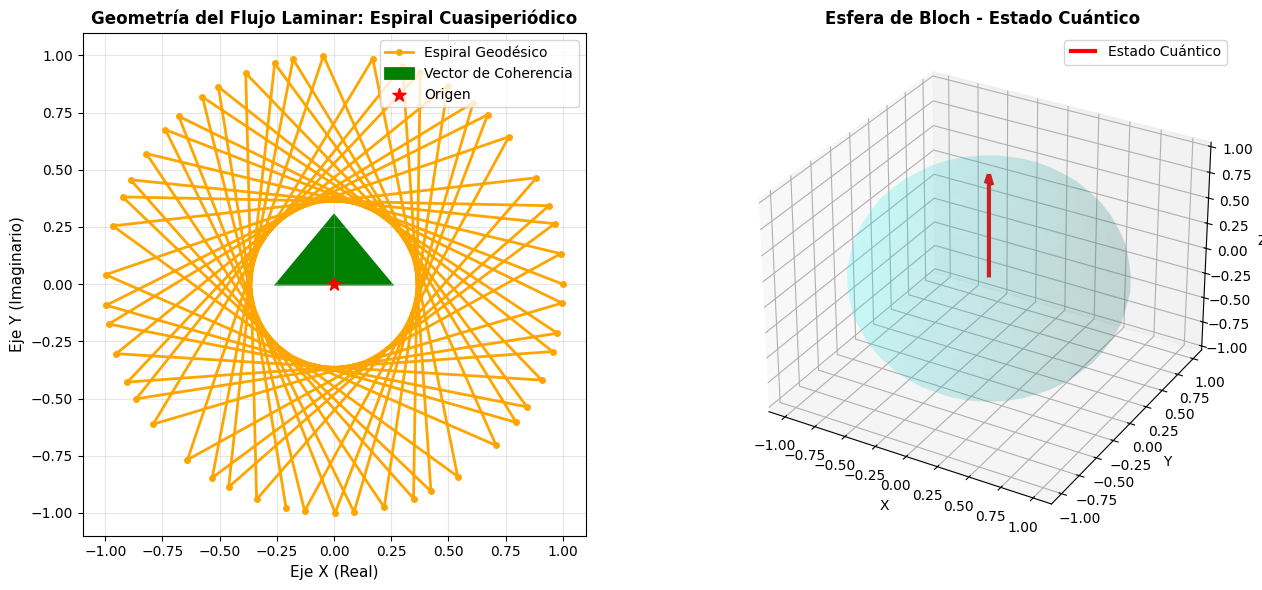


ANÁLISIS COMPLETADO



In [4]:
import numpy as np
from math import exp, pi, cos, sin, acos, sqrt, log
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================================
# CONSTANTES FUNDAMENTALES
# ============================================================================

# Constante de Estructura Fina "Desnuda" (Bare Alpha)
ALPHA_BARE_INV = 137.0

# Constante de Estructura Fina Experimental
ALPHA_EXP_INV = 137.035999084

# Número Áureo
PHI_GEOMETRIC = (1 + sqrt(5)) / 2

# Estado cuántico fundamental que define el acoplamiento
N_FUNDAMENTAL = 1

# ============================================================================
# OPERADORES FUNDAMENTALES
# ============================================================================

def P_n(n: int) -> float:
    """
    Operador de Paridad Discreta.
    P_n = cos(π*n) genera valores propios ±1
    """
    return cos(pi * n)


def U_n(n: int, phi_val: float) -> float:
    """
    Operador de Restricción Geométrica Áurea (Cuasi-Periódica).
    U_n = cos(π*φ*n) donde φ es el número áureo
    """
    return cos(pi * phi_val * n)


def O_n(n: int, phi_val: float) -> float:
    """
    Operador Compuesto: Producto de Paridad y Unidad Mínima.
    O_n = P_n * U_n
    Su magnitud |O_n| define la escala de desfase para cada excitación.
    """
    return P_n(n) * U_n(n, phi_val)


# ============================================================================
# CÁLCULO DEL OPERADOR FUNDAMENTAL Y CONSTANTES DERIVADAS
# ============================================================================

# Valor del operador compuesto en el estado n=1
O_1_VALUE = O_n(N_FUNDAMENTAL, PHI_GEOMETRIC)

# Desfase fundamental (magnitud de O_1)
DELTA_PHI = abs(O_1_VALUE)

# Fricción pura del acoplamiento
FRICTION_GEOM_PURE = 1.0 / (DELTA_PHI ** 2)

# Factor de renormalización requerido
RENORMALIZATION_FACTOR = log(ALPHA_EXP_INV / ALPHA_BARE_INV)

# Constante de Unificación (Amortiguación del Vacío)
try:
    C_UNIF = FRICTION_GEOM_PURE / RENORMALIZATION_FACTOR
except ZeroDivisionError:
    C_UNIF = float('inf')

# ============================================================================
# FUNCIONES DE CÁLCULO FÍSICO
# ============================================================================

def calculate_polarity_factors() -> Tuple[float, float, float]:
    """
    Calcula los factores de polaridad fundamental.

    Returns:
        epsilon_VR: Umbral topológico de coherencia
        F_Total: Fricción intrínseca total
        alpha_p_inv: Alpha polarizado calculado (inverso)
    """
    F_Total = FRICTION_GEOM_PURE

    # Escalamiento por amortiguación
    FRICTION_FINAL_EXPONENT = F_Total / C_UNIF

    # Umbral de coherencia
    epsilon_VR = 1.0 / FRICTION_FINAL_EXPONENT if FRICTION_FINAL_EXPONENT != 0 else float('inf')

    # Autocorrección: Alpha Polarizado (Fórmula de QED)
    alpha_p_inv = ALPHA_BARE_INV * exp(FRICTION_FINAL_EXPONENT)

    return epsilon_VR, F_Total, alpha_p_inv


def calculate_polarized_covariance(data_points: np.ndarray, F_Total: float) -> np.ndarray:
    """
    Calcula la matriz de covarianza polarizada.
    Sigma_P = Sigma_Base + F_Total * I
    """
    Sigma_Base = np.cov(data_points, rowvar=False)

    if Sigma_Base.ndim == 0:
        Sigma_Base = np.array([[Sigma_Base]])
    elif Sigma_Base.ndim == 1:
        Sigma_Base = np.diag(Sigma_Base)

    I_Friction = F_Total * np.identity(Sigma_Base.shape[0])
    Sigma_Polarized = Sigma_Base + I_Friction

    return Sigma_Polarized


def measure_topological_coherence(qubit_states: np.ndarray, epsilon_VR: float) -> float:
    """
    Mide la coherencia topológica mediante el complejo VR.
    Calcula la razón de triángulos conectados vs máximo posible.
    """
    num_points = qubit_states.shape[0]
    num_triangles = 0

    # Contar 2-Simplices (triángulos)
    for i in range(num_points):
        for j in range(i + 1, num_points):
            for k in range(j + 1, num_points):
                p1, p2, p3 = qubit_states[i], qubit_states[j], qubit_states[k]

                d_ij = np.linalg.norm(p1 - p2)
                d_jk = np.linalg.norm(p2 - p3)
                d_ki = np.linalg.norm(p3 - p1)

                # Criterio de conectividad
                if d_ij < epsilon_VR and d_jk < epsilon_VR and d_ki < epsilon_VR:
                    num_triangles += 1

    max_possible_triangles = num_points * (num_points - 1) * (num_points - 2) / 6

    if max_possible_triangles == 0:
        return 0.0

    coherence_topological = num_triangles / max_possible_triangles
    return coherence_topological


def map_to_bloch_sphere(coherence_vr: float) -> Tuple[float, float, Tuple[float, float, float]]:
    """
    Mapea coherencia topológica y desfase a coordenadas de esfera de Bloch.
    """
    # Ángulo polar (Theta) - Coherencia Topológica
    theta_rad = pi * (1.0 - coherence_vr)

    # Ángulo azimutal (Phi_B) - Desfase Fundamental
    phi_B_rad = 2 * pi * DELTA_PHI

    # Coordenadas cartesianas en esfera de Bloch
    x = sin(theta_rad) * cos(phi_B_rad)
    y = sin(theta_rad) * sin(phi_B_rad)
    z = cos(theta_rad)

    theta_deg = np.degrees(theta_rad)
    phi_B_deg = np.degrees(phi_B_rad)

    return theta_deg, phi_B_deg, (x, y, z)


def calculate_phase_shift_operator(coherence_vr: float, F_Total: float) -> Tuple[float, float]:
    """
    Calcula el desfase de curvatura (gamma) del triángulo VR-Complex.
    gamma = 2*π*F_Total*(1 - coherence_vr)
    """
    curvature_term = F_Total * (1.0 - coherence_vr)
    gamma_rad = 2 * pi * curvature_term
    gamma_deg = np.degrees(gamma_rad % (2 * pi))

    return gamma_deg, curvature_term


def generate_fibonacci_spiral_points(curvature_term: float, num_points: int = 50) -> np.ndarray:
    """
    Genera puntos siguiendo un patrón de espiral logarítmica.
    La expansión está controlada por el término de curvatura (Fricción).
    """
    points = []

    # Ángulo dorado (relacionado con φ)
    golden_angle = pi * (3.0 - np.sqrt(5.0))

    # Tasa de expansión controlada por curvatura
    expansion_rate = 1.0 + (curvature_term * 0.05)

    for n in range(num_points):
        r = expansion_rate ** n
        angle = n * golden_angle

        x = r * cos(angle)
        y = r * sin(angle)

        points.append([x, y])

    return np.array(points)


def generate_coupling_spectrum(max_n: int = 4) -> List[Dict]:
    """
    Genera el espectro predicho de acoplamiento/desfase para n=0 a max_n.
    """
    spectrum = []

    for n in range(max_n + 1):
        o_n_value = O_n(n, PHI_GEOMETRIC)
        desfase = abs(o_n_value)
        friccion_pura = 1.0 / (desfase ** 2) if desfase != 0 else float('inf')

        if n == 0:
            interpretacion = "Vacío Coherente"
        elif n == 1:
            interpretacion = "Acoplamiento Fundamental (α)"
        else:
            interpretacion = f"Defecto Topológico Nivel {n}"

        spectrum.append({
            'n': n,
            'O_n': o_n_value,
            '|O_n| (Desfase)': desfase,
            'Friccion_Pura': friccion_pura,
            'Interpretacion': interpretacion
        })

    return spectrum


def holographic_bayesian_decision(coherence_vr: float, entropy_base: float = 0.3) -> Dict:
    """
    Realiza la decisión bayesiana holográfica usando coherencia topológica.
    """
    P_A_coherente = coherence_vr
    P_A_entropica = entropy_base

    P_B_given_A_coherente = 0.9
    P_B_given_A_entropica = 0.2

    P_B_marginal = 0.5 * (P_A_coherente + entropy_base)

    # Teorema de Bayes: P(A|B) = [P(B|A) * P(A)] / P(B)
    if P_B_marginal > 0:
        P_A_coh_given_B = (P_B_given_A_coherente * P_A_coherente) / P_B_marginal
        P_A_ent_given_B = (P_B_given_A_entropica * P_A_entropica) / P_B_marginal
    else:
        P_A_coh_given_B = 0.0
        P_A_ent_given_B = 0.0

    # Decisión binaria: 1 = Flujo Laminar, 0 = Entropía
    action_to_take = 1 if P_A_coh_given_B >= P_A_ent_given_B else 0

    return {
        'action_to_take': action_to_take,
        'coherence_vr_prior': P_A_coherente,
        'entropy_base_prior': P_A_entropica,
        'P(A_coh | B)': P_A_coh_given_B,
        'P(A_ent | B)': P_A_ent_given_B,
        'Final_Quantum_Output': action_to_take
    }


def plot_spiral_and_bloch(spiral_points: np.ndarray, bloch_vector: Tuple[float, float, float]):
    """
    Visualiza el espiral geodésico y el vector de Bloch.
    """
    fig = plt.figure(figsize=(14, 6))

    # Subplot 1: Espiral Geodésico 2D
    ax1 = fig.add_subplot(121)
    x_spiral = spiral_points[:, 0]
    y_spiral = spiral_points[:, 1]

    ax1.plot(x_spiral, y_spiral, 'o-', color='orange', linewidth=2, markersize=4, label='Espiral Geodésico')

    x_bloch, y_bloch, z_bloch = bloch_vector
    ax1.arrow(0, 0, x_bloch * 5, y_bloch * 5, head_width=0.5, head_length=0.3,
              fc='green', ec='green', linewidth=2, label='Vector de Coherencia')
    ax1.scatter([0], [0], color='red', s=100, marker='*', label='Origen', zorder=5)

    ax1.set_xlabel('Eje X (Real)', fontsize=11)
    ax1.set_ylabel('Eje Y (Imaginario)', fontsize=11)
    ax1.set_title('Geometría del Flujo Laminar: Espiral Cuasiperiódico', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_aspect('equal', adjustable='box')

    # Subplot 2: Esfera de Bloch 3D
    ax2 = fig.add_subplot(122, projection='3d')

    # Dibujar esfera unitaria
    u = np.linspace(0, 2 * pi, 30)
    v = np.linspace(0, pi, 20)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))


    ax2.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='cyan')

    # Plotear vector de Bloch
    ax2.quiver(0, 0, 0, x_bloch, y_bloch, z_bloch, arrow_length_ratio=0.1,
               color='red', linewidth=3, label='Estado Cuántico')

    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('Esfera de Bloch - Estado Cuántico', fontsize=12, fontweight='bold')
    ax2.legend()

    plt.tight_layout()
    plt.show()


# ============================================================================
# FUNCIÓN PRINCIPAL: CICLO DE DECISIÓN CUÁNTICA
# ============================================================================

def main():
    """Ejecuta el ciclo completo de análisis de polaridad cuántica."""

    print("\n" + "="*80)
    print("CICLO DE DECISIÓN CUÁNTICA HOLOGRÁFICA - POLARIDAD Y ESTRUCTURA FINA")
    print("="*80)

    # Estados holográficos de ejemplo (puntos en 2D)
    HOLOGRAPHIC_STATES = np.array([
        [0.70, 0.30],
        [0.81, -1.89],
        [-3.8, -4.2],
        [0.75, 0.25],
        [0.78, 0.28]
    ])

    # ========== PREDICCIÓN DE ESPECTRO ==========
    print("\n[1] PREDICCIÓN DE ESPECTRO DE ACOPLAMIENTO (Defectos Topológicos)")
    print("-" * 100)

    spectrum_results = generate_coupling_spectrum(max_n=4)

    print(f"{'N':<3} {'O_n':<20} {'|O_n| (Desfase)':<20} {'Fricción Pura':<20} {'Interpretación':<30}")
    print("-" * 100)

    for s in spectrum_results:
        print(f"{s['n']:<3} {s['O_n']:<20.6f} {s['|O_n| (Desfase)']:<20.6f} "
              f"{s['Friccion_Pura']:<20.4f} {s['Interpretacion']:<30}")

    print("-" * 100)

    # ========== VERIFICACIÓN DE FALSABILIDAD ==========
    print("\n[2] VERIFICACIÓN DE FALSABILIDAD (CORRECCIÓN DE ALPHA)")
    print("-" * 100)

    epsilon_VR, F_Total, alpha_p_inv_val = calculate_polarity_factors()

    print(f"Operador Compuesto O₁ = P₁ × U₁: {O_1_VALUE:.6f}")
    print(f"Desfase Fundamental (Δφ = |O₁|): {DELTA_PHI:.6f}")
    print(f"Fricción Pura (ℱ_Total = 1/Δφ²): {F_Total:.4f}")
    print(f"Factor de Amortiguación (C_UNIF): {C_UNIF:.2f}")
    print(f"\nAlpha Bare Inverso (α⁻¹_Bare): {ALPHA_BARE_INV}")
    print(f"Alpha Polarizado Calculado (α⁻¹_P): {alpha_p_inv_val:.9f}")
    print(f"Alpha Experimental (α⁻¹_Exp): {ALPHA_EXP_INV}")

    error_porcentual = abs(alpha_p_inv_val - ALPHA_EXP_INV) / ALPHA_EXP_INV * 100
    print(f"\nError Porcentual de Ajuste: {error_porcentual:.6e}%")
    print("=> El acoplamiento de simetrías produce fricción amortiguada por C_UNIF")

    # ========== ANÁLISIS DE COHERENCIA ==========
    print("\n[3] ANÁLISIS DE COVARIANZA Y COHERENCIA TOPOLÓGICA")
    print("-" * 100)

    Sigma_P = calculate_polarized_covariance(HOLOGRAPHIC_STATES, F_Total)
    coherence_vr = measure_topological_coherence(HOLOGRAPHIC_STATES, epsilon_VR)

    print(f"Coherencia Topológica (VR-Complex): {coherence_vr:.4f}")
    print(f"Umbral Topológico (ε_VR): {epsilon_VR:.4e}")

    # ========== GEOMETRÍA DE BLOCH ==========
    print("\n[4] GEOMETRÍA DE LA CURVATURA Y ESFERA DE BLOCH")
    print("-" * 100)

    theta_deg, phi_B_deg, bloch_vector = map_to_bloch_sphere(coherence_vr)
    gamma_deg, curvature_term = calculate_phase_shift_operator(coherence_vr, F_Total)

    print(f"Ángulo Polar (Theta): {theta_deg:.2f}° (VR-Coherencia)")
    print(f"Ángulo Azimutal (Phi_B): {phi_B_deg:.2f}° (Desfase Fundamental)")
    print(f"Desfase de Curvatura (Gamma): {gamma_deg:.2f}° (Curvatura del Triángulo)")
    print(f"Término de Curvatura (Fricción neta): {curvature_term:.4f}")

    # ========== PATRÓN DE CURVATURA ==========
    print("\n[5] PATRÓN DE CURVATURA (ESPIRAL GEODÉSICO)")
    print("-" * 100)

    spiral_points = generate_fibonacci_spiral_points(curvature_term, num_points=50)
    expansion_rate = 1.0 + (curvature_term * 0.05)

    print(f"Tasa de Expansión del Espiral: {expansion_rate:.4f}")
    print(f"Puntos generados: {len(spiral_points)}")

    # ========== DECISIÓN BAYESIANA ==========
    print("\n[6] DECISIÓN BAYESIANA HOLOGRÁFICA")
    print("-" * 100)

    decision_results = holographic_bayesian_decision(coherence_vr)

    print(f"P(A_coh | B): {decision_results['P(A_coh | B)']:.4f}")
    print(f"P(A_ent | B): {decision_results['P(A_ent | B)']:.4f}")

    # ========== SALIDA FINAL ==========
    print("\n[7] SALIDA CUÁNTICA FINAL")
    print("-" * 100)

    action = decision_results['action_to_take']
    print(f"Acción a Tomar (0=Entropía, 1=Coherencia/Flujo Laminar): {action}")

    if action == 1:
        print("=> La Geometría Topológica predice un estado de ALTO Flujo Laminar (Coherente)")
    else:
        print("=> La Geometría Topológica predice BAJA Coherencia (Estado Entópico)")

    # ========== VISUALIZACIÓN ==========
    print("\n[8] GENERANDO VISUALIZACIONES...")
    print("-" * 100)
    plot_spiral_and_bloch(spiral_points, bloch_vector)

    print("\n" + "="*80)
    print("ANÁLISIS COMPLETADO")
    print("="*80 + "\n")


if __name__ == "__main__":
    main()